In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.distributions as TD
import torch.optim as optim
from torch.distributions import Normal, Bernoulli, Independent
import torchvision
from torchvision import transforms
from torchvision.utils import make_grid

from collections import defaultdict
from tqdm.notebook import tqdm
from typing import List, Union
import gc
import os
import numpy as np
from sklearn.datasets import make_regression
from sklearn.metrics import r2_score
from IPython.display import Image, display
from IPython.core.display import HTML
from tqdm import tqdm
import matplotlib.pyplot as plt
%matplotlib inline

import matplotlib.animation as animation
from torch.linalg import svd

In [2]:
train_dataset = torchvision.datasets.MNIST(
        root='.', 
        train=True, 
        download=True,  
        transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Lambda(lambda x: x * 2 - 1)
        ])
    )

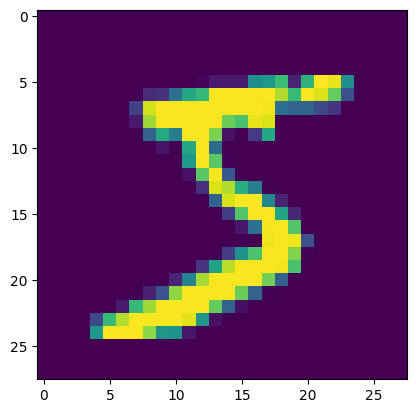

In [3]:
plt.imshow(train_dataset[0][0][0])

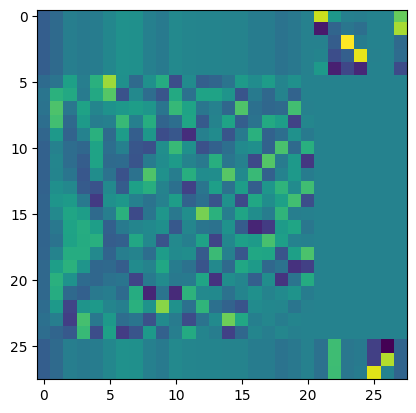

In [4]:
our_sample = train_dataset[0][0][0]

U, S, Vh = svd(our_sample, full_matrices=False)
V = Vh.T
plt.imshow(U)

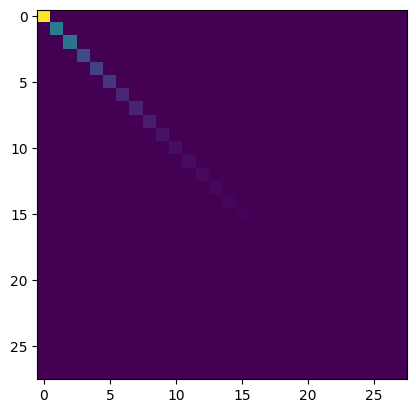

In [5]:
plt.imshow(torch.diag(S))

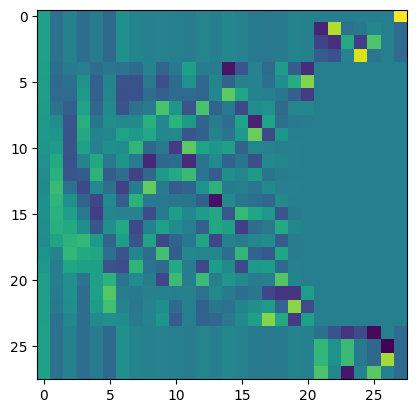

In [6]:
plt.imshow(V)

In [7]:
len(train_dataset)

60000

In [7]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64, 
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    torchvision.datasets.MNIST(
        root='.', 
        train=False, 
        transform=transforms.ToTensor(),
    ),
    batch_size=128, shuffle=True
)

In [8]:
class SinusoidalEmbedding(nn.Module):
    def __init__(self, size: int, scale: float = 1.0):
        super().__init__()
        self.size = size
        self.scale = scale

    def forward(self, x: torch.Tensor):
        x = x * self.scale
        half_size = self.size // 2
        emb = torch.log(torch.Tensor([10000.0]).to(x.device)) / (half_size - 1)
        emb = torch.exp(-emb * torch.arange(half_size).to(x.device))
        emb = x.unsqueeze(-1).float() * emb.unsqueeze(0)
        emb = torch.cat((torch.sin(emb), torch.cos(emb)), dim=-1)
        return emb


class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)

    def forward(self, x, t_emb):
        h = self.norm1(F.gelu(self.conv1(x)))
        h = h + self.time_mlp(t_emb)[:, :, None, None]
        h = self.norm2(F.gelu(self.conv2(h)))
        return h


class DownBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.conv = ConvBlock(in_ch, out_ch, time_emb_dim)
        self.pool = nn.MaxPool2d(2)

    def forward(self, x, t_emb):
        skip = self.conv(x, t_emb)
        return self.pool(skip), skip


class UpBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = ConvBlock(out_ch * 2, out_ch, time_emb_dim)

    def forward(self, x, skip, t_emb):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x, t_emb)


class SimpleUNet(nn.Module):
    def __init__(self, in_channels=3, base_ch=64, time_emb_dim=128):
        super().__init__()
        
        self.time_proj = nn.Sequential(
            SinusoidalEmbedding(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.GELU()
        )
        
        self.down1 = DownBlock(in_channels, base_ch, time_emb_dim)      # 28 -> 14
        self.down2 = DownBlock(base_ch, base_ch * 2, time_emb_dim)      # 14 -> 7
        
        self.bottleneck = ConvBlock(base_ch * 2, base_ch * 4, time_emb_dim)
        
        self.up1 = UpBlock(base_ch * 4, base_ch * 2, time_emb_dim)      # 7 -> 14
        self.up2 = UpBlock(base_ch * 2, base_ch, time_emb_dim)          # 14 -> 28
        
        self.out = nn.Conv2d(base_ch, in_channels, 1)

    def forward(self, x, t):
        '''
        :x input [bs, C, H, W] - image
        :t 1d torch.LongTensor of timesteps
        '''
        t_emb = self.time_proj(t)
        
        x, skip1 = self.down1(x, t_emb)
        x, skip2 = self.down2(x, t_emb)
        
        x = self.bottleneck(x, t_emb)
        
        x = self.up1(x, skip2, t_emb)
        x = self.up2(x, skip1, t_emb)
        
        return self.out(x)

In [10]:
DEVICE = "cuda"

In [11]:
model = SimpleUNet(in_channels=1, base_ch=64, time_emb_dim=64).to(DEVICE)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)

In [12]:
sum([p.numel() for p in model.parameters()])

1910017

In [13]:
def svd_forward_process(image, t):
    U, S, Vh = svd(image, full_matrices=False)
    V = Vh.T
    
    U_slice = U[:, :t]
    V_slice = V[:, :t]
    S_slice = S[:t]

    restored = U_slice @ torch.diag(S_slice) @ V_slice.T
    
    return restored

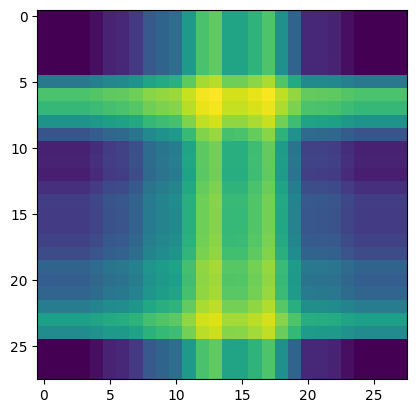

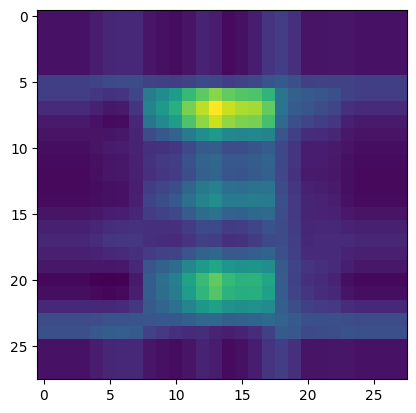

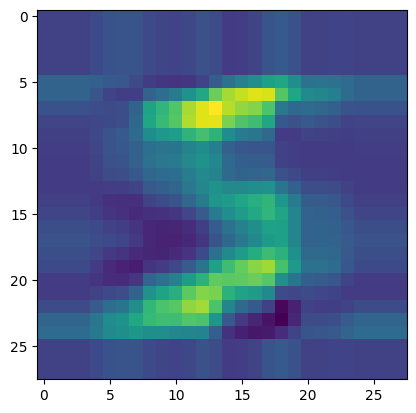

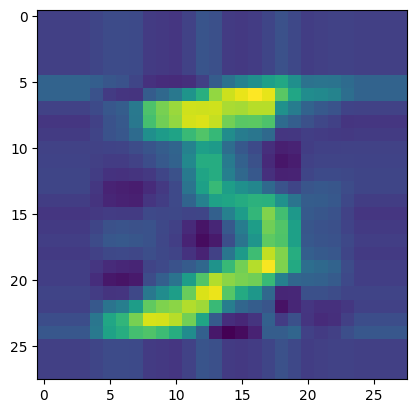

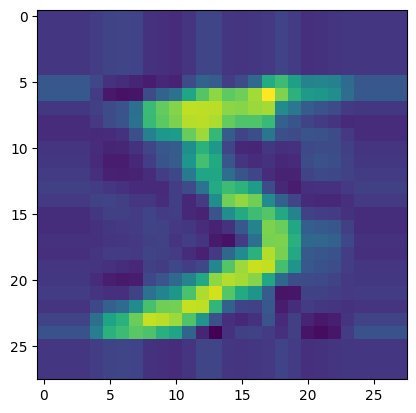

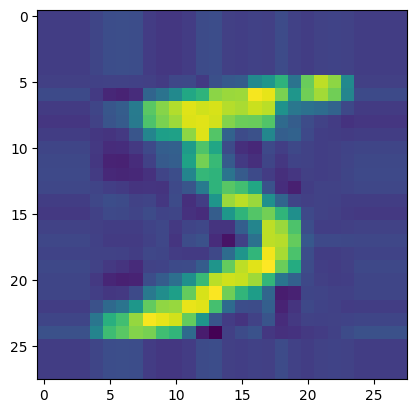

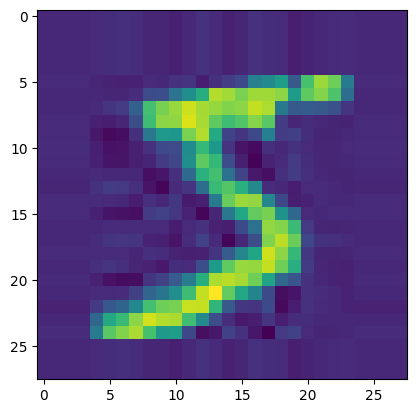

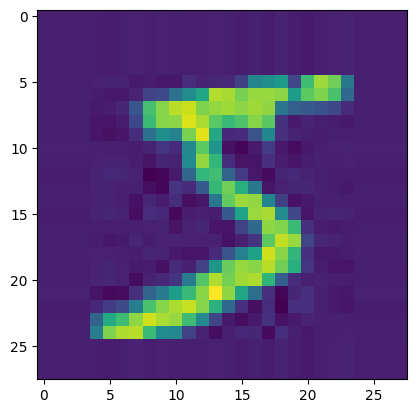

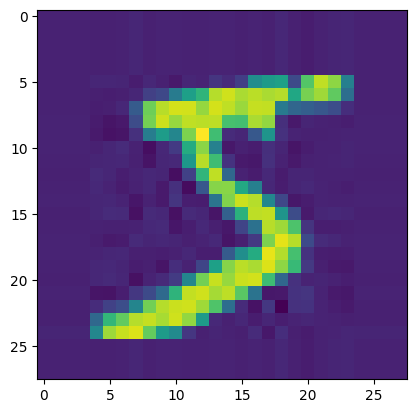

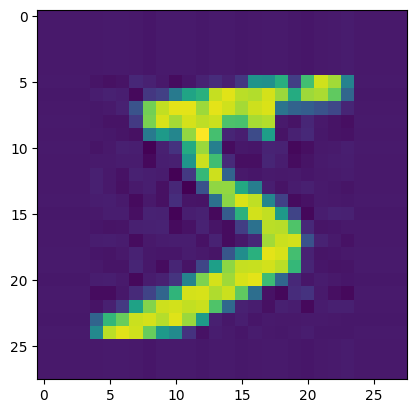

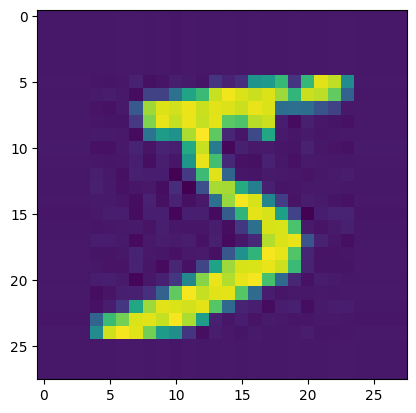

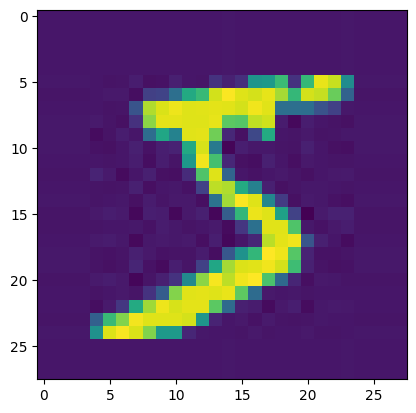

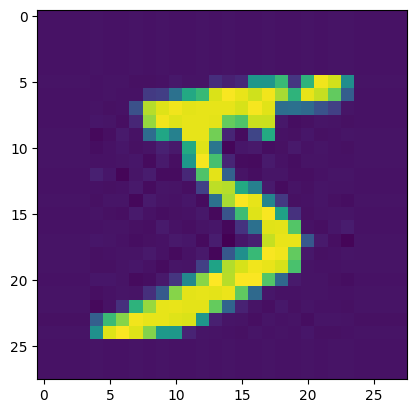

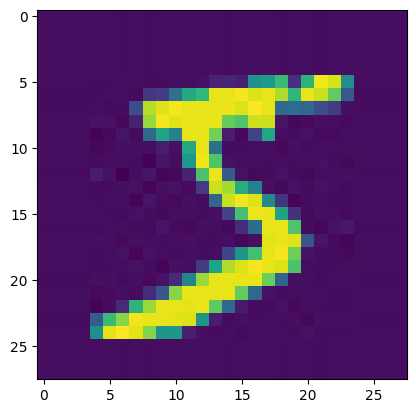

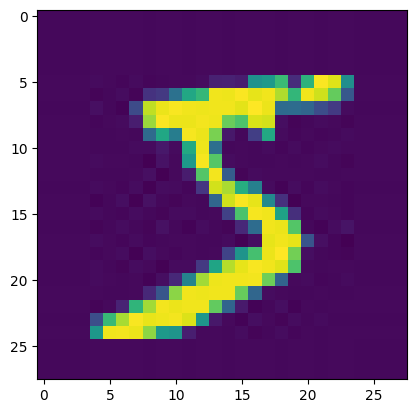

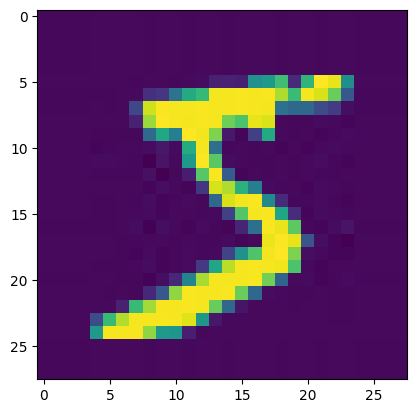

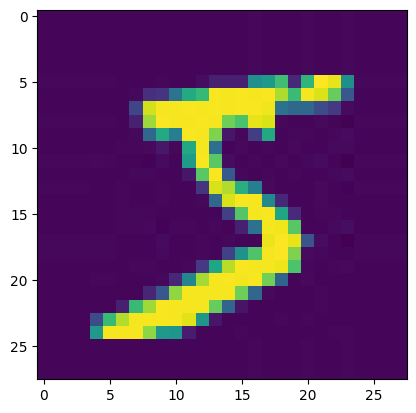

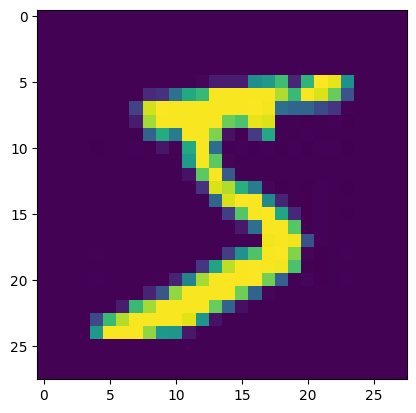

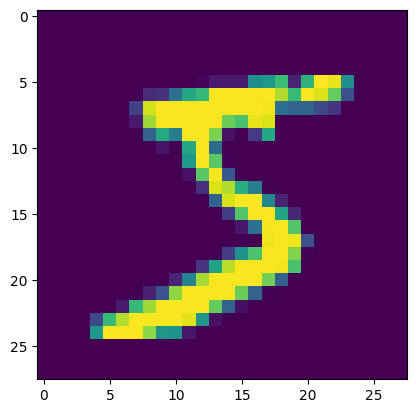

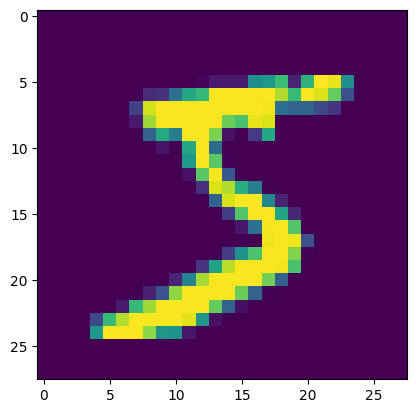

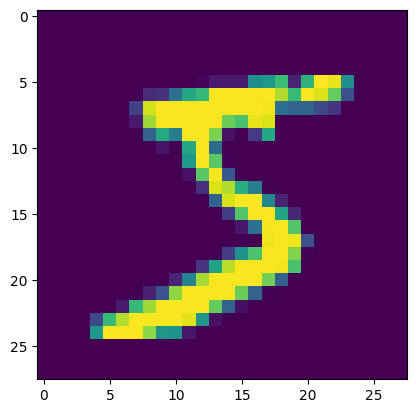

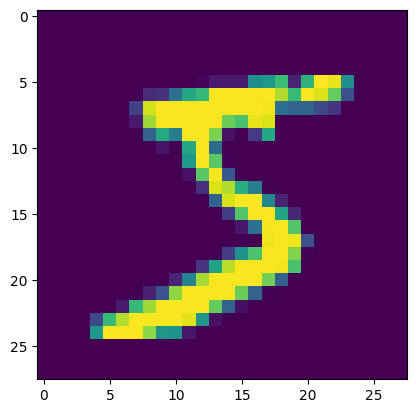

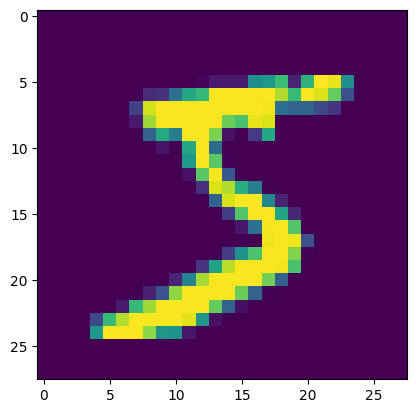

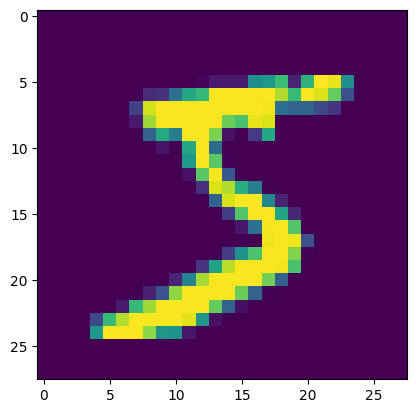

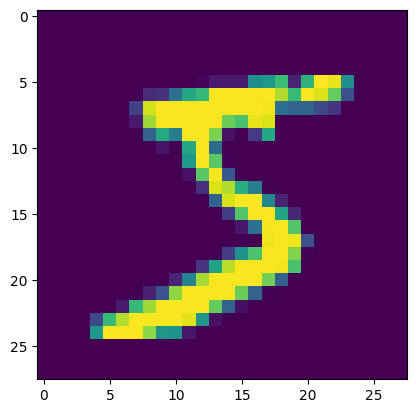

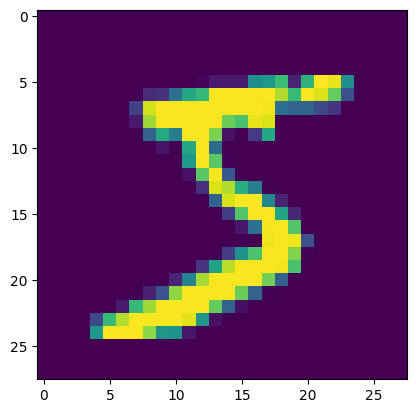

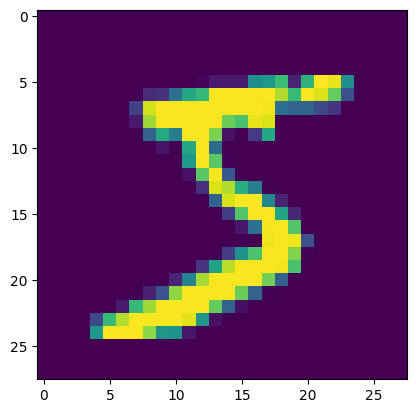

In [14]:
for n in range(1, 28):
    src = svd_forward_process(our_sample, n)
    plt.imshow(src)
    plt.show()

# Calculate Singular Values across Dataset

In [15]:
def get_scaled_singular_values(image):
    U, S, Vh = torch.linalg.svd(image, full_matrices=False)
    
    return S / torch.sum(S.flatten())

In [16]:
all_singular_weight = []

for i in tqdm(range(len(train_dataset))):
    all_singular_weight.append(get_scaled_singular_values(train_dataset[i][0][0]).unsqueeze(dim=0))

100%|██████████| 60000/60000 [00:07<00:00, 7996.97it/s]


In [17]:
weights = torch.mean(torch.cat(all_singular_weight, dim=0), dim=0)
weights.shape

torch.Size([28])

In [18]:
weights

tensor([3.9425e-01, 1.5373e-01, 1.1901e-01, 8.8725e-02, 6.5209e-02, 4.6306e-02,
        3.4102e-02, 2.4981e-02, 1.9028e-02, 1.4724e-02, 1.1543e-02, 8.8591e-03,
        6.7499e-03, 4.8303e-03, 3.3991e-03, 2.1376e-03, 1.3128e-03, 6.6371e-04,
        3.1318e-04, 9.7114e-05, 1.9004e-05, 2.2413e-08, 2.2410e-08, 2.2410e-08,
        2.2410e-08, 2.2410e-08, 2.2389e-08, 5.9256e-09])

# Train

In [21]:
losses = []

log_every_n = 10
num_train_steps = 1500
num_epoches = 10
step = 0 
HIGH = 28

model.train()

for epoch in range(num_epoches):
    for images, labels in tqdm(train_loader):
        batch_src = []

        rec_step = torch.multinomial(weights, images.shape[0], replacement=True) + 1
                
        for i in range(images.shape[0]):
            our_sample = images[i][0]
            
            src = svd_forward_process(our_sample, rec_step[i])

            batch_src.append(src.unsqueeze(dim=0).unsqueeze(dim=0))

        src = torch.cat(batch_src, dim=0).to(DEVICE)
        target = images.to(DEVICE)
        rec_step = rec_step.to(DEVICE)

        optimizer.zero_grad()
        output = model(src, rec_step)

        loss = F.l1_loss(output, target)
    
        if step % log_every_n == 0:
            print(loss.item())
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
    
        losses.append(loss.item())
    
        step += 1

        if step >= num_train_steps:
            break
            
    if step >= num_train_steps:
        break

  0%|          | 1/938 [00:00<10:04,  1.55it/s]

0.8176714777946472


  2%|▏         | 20/938 [00:00<00:29, 30.64it/s]

0.23129503428936005
0.18062402307987213


  4%|▍         | 39/938 [00:01<00:18, 47.72it/s]

0.16925616562366486
0.20863834023475647


  6%|▌         | 57/938 [00:01<00:18, 47.97it/s]

0.17419195175170898


  7%|▋         | 70/938 [00:01<00:16, 53.40it/s]

0.13736075162887573
0.1585615873336792


 10%|▉         | 90/938 [00:02<00:14, 56.72it/s]

0.14670048654079437
0.14271190762519836


 12%|█▏        | 109/938 [00:02<00:14, 57.74it/s]

0.12221670150756836
0.12906478345394135


 14%|█▎        | 127/938 [00:02<00:14, 54.99it/s]

0.11658790707588196
0.13465169072151184


 16%|█▌        | 146/938 [00:03<00:14, 55.83it/s]

0.12230803072452545
0.12138977646827698


 18%|█▊        | 165/938 [00:03<00:14, 53.41it/s]

0.10283038765192032
0.11803228408098221


 20%|██        | 191/938 [00:04<00:13, 53.56it/s]

0.10637019574642181
0.09895122051239014


 22%|██▏       | 209/938 [00:04<00:13, 54.83it/s]

0.09674772620201111
0.09161219000816345


 24%|██▍       | 227/938 [00:04<00:13, 53.48it/s]

0.1009737104177475
0.0990501418709755


 27%|██▋       | 251/938 [00:05<00:12, 53.89it/s]

0.08268723636865616
0.10028048604726791


 28%|██▊       | 263/938 [00:05<00:13, 50.78it/s]

0.09211499243974686


 30%|██▉       | 281/938 [00:05<00:15, 42.82it/s]

0.09337614476680756
0.08360710740089417


 32%|███▏      | 301/938 [00:06<00:12, 53.04it/s]

0.09581264108419418
0.10249573737382889


 34%|███▍      | 320/938 [00:06<00:11, 54.19it/s]

0.08083096146583557
0.08597521483898163


 36%|███▌      | 339/938 [00:06<00:10, 55.88it/s]

0.08150981366634369
0.08890257030725479


 38%|███▊      | 358/938 [00:07<00:10, 56.16it/s]

0.07462360709905624
0.10427393019199371


 40%|████      | 377/938 [00:07<00:10, 55.01it/s]

0.08646747469902039
0.08353240042924881


 42%|████▏     | 396/938 [00:08<00:10, 49.52it/s]

0.08659423142671585


 43%|████▎     | 408/938 [00:08<00:10, 51.66it/s]

0.07956776767969131
0.08204968273639679


 45%|████▌     | 426/938 [00:08<00:09, 51.80it/s]

0.08129242807626724
0.08621813356876373


 47%|████▋     | 445/938 [00:08<00:09, 52.93it/s]

0.07594669610261917


 49%|████▉     | 458/938 [00:09<00:08, 54.45it/s]

0.07551375776529312
0.07228902727365494


 51%|█████     | 477/938 [00:09<00:08, 56.12it/s]

0.08138050884008408
0.08131327480077744


 53%|█████▎    | 501/938 [00:09<00:07, 55.63it/s]

0.07093694061040878
0.0719439834356308


 56%|█████▌    | 521/938 [00:10<00:07, 57.19it/s]

0.07962317019701004
0.06646453589200974


 58%|█████▊    | 540/938 [00:10<00:06, 57.85it/s]

0.07715710997581482
0.07717239111661911


 60%|█████▉    | 559/938 [00:10<00:06, 55.91it/s]

0.07520346343517303
0.06511126458644867


 62%|██████▏   | 578/938 [00:11<00:06, 54.78it/s]

0.07317645102739334
0.07760906219482422


 64%|██████▎   | 597/938 [00:11<00:06, 55.18it/s]

0.07738280296325684
0.06627874076366425


 66%|██████▌   | 616/938 [00:12<00:05, 55.29it/s]

0.07308569550514221
0.07392113655805588


 68%|██████▊   | 635/938 [00:12<00:05, 53.62it/s]

0.06849121302366257
0.0652155801653862


 70%|██████▉   | 655/938 [00:12<00:05, 49.55it/s]

0.07675686478614807


 70%|███████   | 661/938 [00:13<00:09, 28.91it/s]

0.07014495134353638


 71%|███████▏  | 670/938 [00:13<00:15, 16.87it/s]

0.07055744528770447


 73%|███████▎  | 682/938 [00:15<00:31,  8.09it/s]

0.08659631013870239


 74%|███████▎  | 691/938 [00:16<00:38,  6.44it/s]

0.063921719789505


 75%|███████▍  | 702/938 [00:18<00:37,  6.27it/s]

0.06734319776296616


 76%|███████▌  | 712/938 [00:19<00:28,  8.04it/s]

0.07565455883741379


 77%|███████▋  | 722/938 [00:21<00:31,  6.88it/s]

0.07261177897453308


 78%|███████▊  | 731/938 [00:22<00:36,  5.64it/s]

0.07114872336387634


 80%|███████▉  | 750/938 [00:23<00:05, 32.64it/s]

0.06854955106973648
0.07487978786230087


 82%|████████▏ | 770/938 [00:24<00:03, 52.29it/s]

0.069404236972332
0.06522511690855026


 83%|████████▎ | 777/938 [00:24<00:02, 55.82it/s]

0.07278279215097427


 85%|████████▌ | 800/938 [00:25<00:04, 27.76it/s]

0.06435241550207138
0.07566503435373306


 88%|████████▊ | 821/938 [00:25<00:02, 45.84it/s]

0.0793568342924118
0.06299054622650146


 90%|████████▉ | 842/938 [00:26<00:01, 57.37it/s]

0.07251223921775818
0.06784780323505402


 91%|█████████ | 849/938 [00:26<00:01, 59.22it/s]

0.06240822374820709


 93%|█████████▎| 870/938 [00:26<00:01, 52.52it/s]

0.06690981984138489
0.07251553237438202


 95%|█████████▍| 891/938 [00:26<00:00, 60.10it/s]

0.06806536763906479
0.0662866085767746


 97%|█████████▋| 912/938 [00:27<00:00, 63.40it/s]

0.06567641347646713
0.07428151369094849


100%|█████████▉| 934/938 [00:27<00:00, 66.99it/s]

0.06067807227373123
0.06864339113235474


  2%|▏         | 15/938 [00:00<00:13, 70.78it/s]

0.08169449120759964
0.07278451323509216


  3%|▎         | 31/938 [00:00<00:12, 71.50it/s]

0.07458661496639252
0.06581757962703705


  6%|▌         | 55/938 [00:00<00:12, 70.49it/s]

0.06121089309453964
0.07801193743944168


  8%|▊         | 71/938 [00:01<00:12, 70.06it/s]

0.06327871233224869
0.06459105759859085


  9%|▉         | 86/938 [00:01<00:12, 69.33it/s]

0.06548397988080978


 11%|█         | 100/938 [00:01<00:14, 59.22it/s]

0.06723639369010925
0.05934029445052147


 13%|█▎        | 121/938 [00:01<00:13, 62.75it/s]

0.06950841844081879
0.07105796039104462


 15%|█▌        | 142/938 [00:02<00:12, 63.77it/s]

0.06243617460131645
0.07627742737531662


 17%|█▋        | 163/938 [00:02<00:12, 64.12it/s]

0.0682779997587204
0.06728596985340118


 19%|█▉        | 177/938 [00:02<00:12, 58.93it/s]

0.07231172174215317


 20%|██        | 189/938 [00:02<00:13, 54.43it/s]

0.07549594342708588
0.06431914865970612


 22%|██▏       | 208/938 [00:03<00:13, 52.91it/s]

0.06593014299869537
0.06138746067881584


 25%|██▍       | 233/938 [00:03<00:13, 51.67it/s]

0.06453903019428253
0.06072716787457466


 27%|██▋       | 252/938 [00:04<00:13, 52.36it/s]

0.061084941029548645
0.057272471487522125


 29%|██▉       | 271/938 [00:04<00:12, 52.18it/s]

0.061819832772016525
0.0666375607252121


 31%|███       | 289/938 [00:04<00:12, 51.33it/s]

0.05227501317858696
0.07350856065750122


 33%|███▎      | 313/938 [00:05<00:11, 52.84it/s]

0.06463926285505295
0.06502017378807068


 35%|███▌      | 332/938 [00:05<00:11, 53.10it/s]

0.055872827768325806
0.06642132997512817


 37%|███▋      | 351/938 [00:06<00:10, 53.53it/s]

0.07242836803197861
0.06249189376831055


 39%|███▉      | 370/938 [00:06<00:10, 56.03it/s]

0.07093268632888794
0.07688698172569275


 41%|████▏     | 389/938 [00:06<00:09, 56.80it/s]

0.06568484008312225
0.06553101539611816


 44%|████▎     | 409/938 [00:07<00:09, 58.06it/s]

0.06408818811178207
0.06398407369852066


 46%|████▌     | 428/938 [00:07<00:09, 56.11it/s]

0.05951319634914398
0.07272591441869736


 48%|████▊     | 454/938 [00:07<00:08, 58.20it/s]

0.0619637630879879
0.07069095224142075


 51%|█████     | 474/938 [00:08<00:08, 57.88it/s]

0.06126493588089943
0.0645257756114006


 52%|█████▏    | 492/938 [00:08<00:08, 55.63it/s]

0.06303154677152634
0.06457868963479996


 54%|█████▍    | 511/938 [00:08<00:07, 56.16it/s]

0.06626641750335693
0.05606420710682869


 57%|█████▋    | 532/938 [00:09<00:07, 53.21it/s]

0.0550631508231163


 57%|█████▋    | 538/938 [00:09<00:09, 40.24it/s]

0.05689988657832146


 59%|█████▉    | 553/938 [00:09<00:07, 52.13it/s]

0.05985317379236221
0.05619211494922638


 60%|█████▉    | 561/938 [00:09<00:06, 57.27it/s]


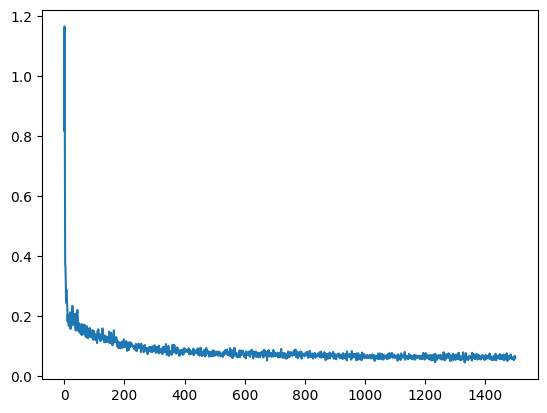

In [22]:
plt.plot([i for i in range(len(losses))], losses)

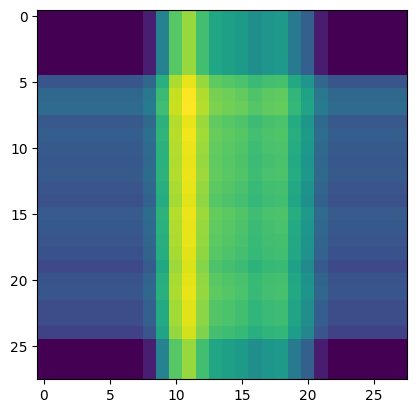

In [23]:
src = svd_forward_process(train_dataset[3][0][0], 1)

plt.imshow(src)

MovieWriter ffmpeg unavailable; using Pillow instead.


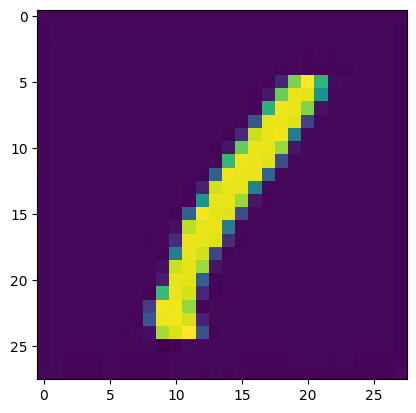

In [24]:
NFE = 28

imgs = []
fig = plt.figure()

x_t = src[None, None].to(DEVICE)

plot = plt.imshow(x_t[0][0].cpu())
imgs.append([plot])

model.eval()

for t in range(1, NFE):
    with torch.no_grad():
        x_0_approx = model(
            x_t.to(DEVICE), 
            torch.tensor(t).to(DEVICE)
        )
    
    x_t = svd_forward_process(x_0_approx[0, 0], t + 1)[None, None]
        
    plot = plt.imshow(x_t[0][0].cpu())
    imgs.append([plot])

ani = animation.ArtistAnimation(fig, imgs, interval=200, blit=True)
ani.save('svd_cold_scheme_1_generation.gif')

MovieWriter ffmpeg unavailable; using Pillow instead.


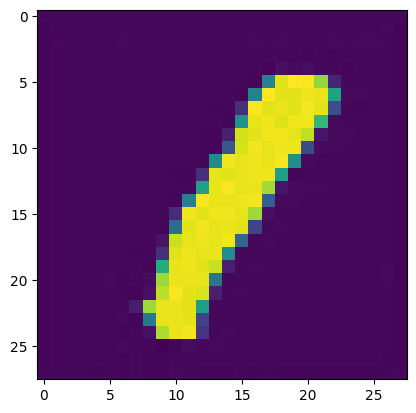

In [25]:
NFE = 28

imgs = []
fig = plt.figure()

x_t = src[None, None].to(DEVICE)

plot = plt.imshow(x_t[0][0].cpu())
imgs.append([plot])

model.eval()

for t in range(1, NFE):
    with torch.no_grad():
        x_0_approx = model(
            x_t.to(DEVICE), 
            torch.tensor(t).to(DEVICE)
        )
    
    x_t = x_0_approx - svd_forward_process(x_0_approx[0, 0], t)[None, None] + svd_forward_process(x_0_approx[0, 0], t + 1)[None, None]
        
    plot = plt.imshow(x_t[0][0].cpu())
    imgs.append([plot])

ani = animation.ArtistAnimation(fig, imgs, interval=200, blit=True)
ani.save('svd_cold_scheme_2_generation.gif')

# Fit Prior

In [26]:
from sklearn.mixture import GaussianMixture
import numpy as np


def get_rank1_scaled(image):
    U, S, Vh = torch.linalg.svd(image, full_matrices=False)
    
    # Get rank-1 components
    u1 = U[:, 0]  # shape (28,)
    v1 = Vh[0, :]  # shape (28,) - Note: Vh[0] not V[:, 0]
    sigma1 = S[0]  # scalar
    
    # SCALE the vectors by √σ₁ to preserve reconstruction
    u_scaled = u1 * torch.sqrt(sigma1)
    v_scaled = v1 * torch.sqrt(sigma1)
    
    # Concatenate: [√σ*u, √σ*v, σ]
    # This preserves the outer product relationship
    return torch.cat([u_scaled, v_scaled, sigma1.unsqueeze(0)]).unsqueeze(0)

# Reconstruction from this format:
def reconstruct_from_scaled(vector):
    u_scaled = vector[:28]
    v_scaled = vector[28:56]
    sigma = vector[56]
    
    # image = (√σ*u) ⊗ (√σ*v) = σ * (u ⊗ v)
    image = torch.outer(u_scaled, v_scaled)
    return image

In [27]:
X = []

for i in tqdm(range(len(train_dataset))):
    X.append(get_rank1_scaled(train_dataset[i][0][0]))
    
X = torch.cat(X)
X.shape

100%|██████████| 60000/60000 [00:08<00:00, 6989.43it/s]


torch.Size([60000, 57])

In [28]:
n_components = 10
gmm = GaussianMixture(n_components=n_components, covariance_type='full', verbose=2, random_state=42)
gmm.fit(X.numpy())

Initialization 0
  Iteration 10	 time lapse 8.46327s	 ll change 0.34433
  Iteration 20	 time lapse 22.75134s	 ll change 0.04222
  Iteration 30	 time lapse 7.93663s	 ll change 0.01366
Initialization converged. time lapse 45.44124s	 lower bound 136.16629.


,n_components,10
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


In [29]:
sampled_vectors = gmm.sample(n_samples=100)[0]
sampled_vectors.shape

/home/user/conda/envs/kandinsky-cuda12.8/lib/python3.12/site-packages/sklearn/mixture/_base.py:443: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  rng.multivariate_normal(mean, covariance, int(sample))


(100, 57)

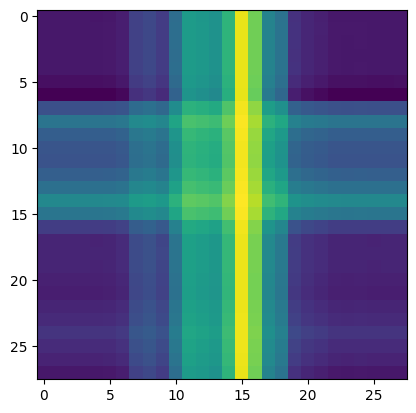

In [30]:
src = reconstruct_from_scaled(torch.tensor(sampled_vectors[23])).float()
plt.imshow(src)

MovieWriter ffmpeg unavailable; using Pillow instead.


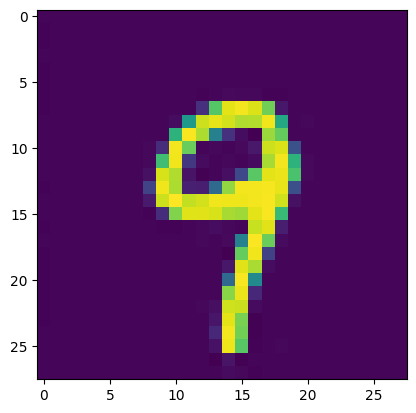

In [31]:
NFE = 28

imgs = []
fig = plt.figure()

x_t = src[None, None].to(DEVICE)

plot = plt.imshow(x_t[0][0].cpu())
imgs.append([plot])

model.eval()

for t in range(1, NFE):
    with torch.no_grad():
        x_0_approx = model(
            x_t.to(DEVICE), 
            torch.tensor(t).to(DEVICE)
        )
    
    x_t = svd_forward_process(x_0_approx[0, 0], t + 1)[None, None]
        
    plot = plt.imshow(x_t[0][0].cpu())
    imgs.append([plot])

ani = animation.ArtistAnimation(fig, imgs, interval=200, blit=True)
ani.save('svd_cold_scheme_1_generation.gif')

MovieWriter ffmpeg unavailable; using Pillow instead.


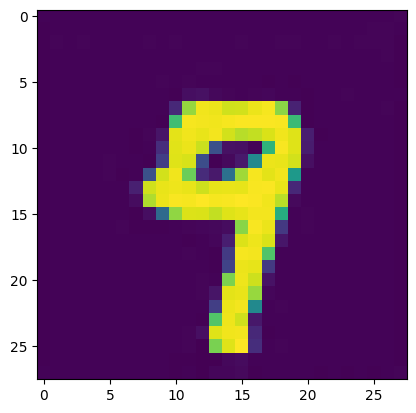

In [32]:
NFE = 28

imgs = []
fig = plt.figure()

x_t = src[None, None].to(DEVICE)

plot = plt.imshow(x_t[0][0].cpu())
imgs.append([plot])

model.eval()

for t in range(1, NFE):
    with torch.no_grad():
        x_0_approx = model(
            x_t.to(DEVICE), 
            torch.tensor(t).to(DEVICE)
        )
    
    x_t = x_0_approx - svd_forward_process(x_0_approx[0, 0], t)[None, None] + svd_forward_process(x_0_approx[0, 0], t + 1)[None, None]
        
    plot = plt.imshow(x_t[0][0].cpu())
    imgs.append([plot])

ani = animation.ArtistAnimation(fig, imgs, interval=200, blit=True)
ani.save('svd_cold_scheme_2_generation.gif')

# Generate

In [33]:
import os
from PIL import Image

num_samples = 10000
batch_size = 1024
num_steps = 10

model.eval()

for num_steps in range(1, 28):
    save_dir = f'MNIST/generate_svd_cold_scheme_1/{num_steps}'
    os.makedirs(save_dir, exist_ok=True)

    count = 0
    for batch_idx in tqdm(range(num_samples // batch_size + 1), desc='Generating and saving images'):
        current_batch_size = min(batch_size, num_samples - count)
        if current_batch_size <= 0:
            break
        
        sampled_vectors = gmm.sample(n_samples=batch_size)[0]
        x_t = torch.cat([reconstruct_from_scaled(torch.tensor(v).float())[None, None] for v in sampled_vectors], dim=0).to(DEVICE)
                
        with torch.no_grad():
            for t in range(1, num_steps):
                x_0_approx = model(
                    x_t.to(DEVICE), 
                    torch.tensor(t).repeat(x_t.shape[0]).to(DEVICE)
                )
                
                x_t = torch.cat([svd_forward_process(x_0_approx[i, 0], t + 1)[None, None] for i in range(x_0_approx.shape[0])], dim=0)
        
        for i in range(current_batch_size):
            img = x_t[i][0].cpu()
            
            img_np = ((img.numpy() + 1) * 127.5).clip(0, 255).astype(np.uint8)
            pil_img = Image.fromarray(img_np, mode='L')
            
            pil_img.save(os.path.join(save_dir, f'gen_{count:05d}.png'))
            count += 1

    print(f'Saved {count} generated images to {save_dir}')

Generating and saving images:   0%|          | 0/10 [00:00<?, ?it/s]/home/user/conda/envs/kandinsky-cuda12.8/lib/python3.12/site-packages/sklearn/mixture/_base.py:443: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  rng.multivariate_normal(mean, covariance, int(sample))
Generating and saving images: 100%|██████████| 10/10 [00:16<00:00,  1.62s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/1


Generating and saving images: 100%|██████████| 10/10 [00:19<00:00,  1.93s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/2


Generating and saving images: 100%|██████████| 10/10 [00:23<00:00,  2.32s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/3


Generating and saving images: 100%|██████████| 10/10 [00:26<00:00,  2.60s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/4


Generating and saving images: 100%|██████████| 10/10 [00:29<00:00,  2.95s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/5


Generating and saving images: 100%|██████████| 10/10 [00:33<00:00,  3.35s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/6


Generating and saving images: 100%|██████████| 10/10 [00:37<00:00,  3.73s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/7


Generating and saving images: 100%|██████████| 10/10 [00:39<00:00,  4.00s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/8


Generating and saving images: 100%|██████████| 10/10 [00:43<00:00,  4.34s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/9


Generating and saving images: 100%|██████████| 10/10 [00:47<00:00,  4.78s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/10


Generating and saving images: 100%|██████████| 10/10 [00:50<00:00,  5.09s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/11


Generating and saving images: 100%|██████████| 10/10 [00:55<00:00,  5.54s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/12


Generating and saving images: 100%|██████████| 10/10 [00:58<00:00,  5.82s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/13


Generating and saving images: 100%|██████████| 10/10 [01:01<00:00,  6.18s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/14


Generating and saving images: 100%|██████████| 10/10 [01:05<00:00,  6.53s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/15


Generating and saving images: 100%|██████████| 10/10 [01:08<00:00,  6.83s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/16


Generating and saving images: 100%|██████████| 10/10 [01:09<00:00,  6.91s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/17


Generating and saving images: 100%|██████████| 10/10 [01:14<00:00,  7.48s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/18


Generating and saving images: 100%|██████████| 10/10 [01:21<00:00,  8.17s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/19


Generating and saving images: 100%|██████████| 10/10 [01:23<00:00,  8.35s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/20


Generating and saving images: 100%|██████████| 10/10 [01:27<00:00,  8.77s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/21


Generating and saving images: 100%|██████████| 10/10 [01:29<00:00,  8.98s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/22


Generating and saving images: 100%|██████████| 10/10 [01:32<00:00,  9.21s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/23


Generating and saving images: 100%|██████████| 10/10 [01:34<00:00,  9.50s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/24


Generating and saving images: 100%|██████████| 10/10 [01:39<00:00,  9.96s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/25


Generating and saving images: 100%|██████████| 10/10 [01:42<00:00, 10.24s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/26


Generating and saving images: 100%|██████████| 10/10 [01:46<00:00, 10.70s/it]

Saved 10000 generated images to MNIST/generate_svd_cold_scheme_1/27


In [ ]:
import os
from PIL import Image

num_samples = 10000
batch_size = 1024
num_steps = 10

model.eval()

for num_steps in range(1, 28):
    save_dir = f'MNIST/generate_svd_cold_scheme_2/{num_steps}'
    os.makedirs(save_dir, exist_ok=True)

    count = 0
    for batch_idx in tqdm(range(num_samples // batch_size + 1), desc='Generating and saving images'):
        current_batch_size = min(batch_size, num_samples - count)
        if current_batch_size <= 0:
            break
        
        sampled_vectors = gmm.sample(n_samples=batch_size)[0]
        x_t = torch.cat([reconstruct_from_scaled(torch.tensor(v).float())[None, None] for v in sampled_vectors], dim=0).to(DEVICE)
                
        with torch.no_grad():
            for t in range(1, num_steps):
                x_0_approx = model(
                    x_t.to(DEVICE), 
                    torch.tensor(t).repeat(x_t.shape[0]).to(DEVICE)
                )
                
                x_t = x_0_approx - torch.cat([svd_forward_process(x_0_approx[i, 0], t)[None, None] for i in range(x_0_approx.shape[0])], dim=0) + torch.cat([svd_forward_process(x_0_approx[i, 0], t + 1)[None, None] for i in range(x_0_approx.shape[0])], dim=0)

        
        for i in range(current_batch_size):
            img = x_t[i][0].cpu()
            
            img_np = ((img.numpy() + 1) * 127.5).clip(0, 255).astype(np.uint8)
            pil_img = Image.fromarray(img_np, mode='L')
            
            pil_img.save(os.path.join(save_dir, f'gen_{count:05d}.png'))
            count += 1

    print(f'Saved {count} generated images to {save_dir}')

Generating and saving images: 100%|██████████| 10/10 [00:12<00:00,  1.29s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_2/1


Generating and saving images: 100%|██████████| 10/10 [00:23<00:00,  2.31s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_2/2


Generating and saving images: 100%|██████████| 10/10 [00:30<00:00,  3.05s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_2/3


Generating and saving images: 100%|██████████| 10/10 [01:05<00:00,  6.59s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_2/4


Generating and saving images: 100%|██████████| 10/10 [01:12<00:00,  7.29s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_2/5


Generating and saving images: 100%|██████████| 10/10 [01:32<00:00,  9.27s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_2/6


Generating and saving images: 100%|██████████| 10/10 [01:43<00:00, 10.31s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_2/7


Generating and saving images: 100%|██████████| 10/10 [01:50<00:00, 11.06s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_2/8


Generating and saving images: 100%|██████████| 10/10 [02:10<00:00, 13.04s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_2/9


Generating and saving images: 100%|██████████| 10/10 [02:17<00:00, 13.73s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_2/10


Generating and saving images: 100%|██████████| 10/10 [02:36<00:00, 15.61s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_2/11


Generating and saving images: 100%|██████████| 10/10 [01:45<00:00, 10.58s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_2/12


Generating and saving images: 100%|██████████| 10/10 [01:38<00:00,  9.81s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_2/13


Generating and saving images: 100%|██████████| 10/10 [01:43<00:00, 10.33s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_2/14


Generating and saving images: 100%|██████████| 10/10 [01:50<00:00, 11.05s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_2/15


Generating and saving images: 100%|██████████| 10/10 [01:57<00:00, 11.72s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_2/16


Generating and saving images: 100%|██████████| 10/10 [02:03<00:00, 12.34s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_2/17


Generating and saving images: 100%|██████████| 10/10 [02:10<00:00, 13.10s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_2/18


Generating and saving images: 100%|██████████| 10/10 [02:15<00:00, 13.53s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_2/19


Generating and saving images: 100%|██████████| 10/10 [02:31<00:00, 15.12s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_2/20


Generating and saving images: 100%|██████████| 10/10 [02:33<00:00, 15.36s/it]


Saved 10000 generated images to MNIST/generate_svd_cold_scheme_2/21


Generating and saving images:  20%|██        | 2/10 [00:31<02:07, 15.93s/it]

In [38]:
import pandas as pd

fid_results = "fid_svd_cold_scheme_1_results.csv"
df = pd.read_csv(fid_results)
df = df.iloc[1:]

In [39]:
df["steps"] = df["path1"].apply(lambda x: int(x.split("_")[-1].split("/")[-1]))

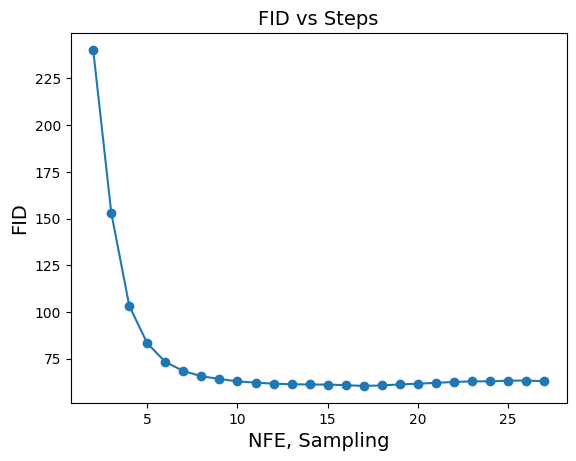

In [40]:
plt.plot(df["steps"], df["fid"], "-o")
plt.xlabel("NFE, Sampling", fontsize=14)
plt.ylabel("FID", fontsize=14)
plt.title("FID vs Steps", fontsize=14)
plt.show()

In [41]:
import pandas as pd

fid_results = "fid_svd_cold_scheme_2_results.csv"
df = pd.read_csv(fid_results)
df = df.iloc[1:]

In [ ]:
df["steps"] = df["path1"].apply(lambda x: int(x.split("_")[-1].split("/")[-1]))

In [42]:
plt.plot(df["steps"], df["fid"], "-o")
plt.xlabel("NFE, Sampling", fontsize=14)
plt.ylabel("FID", fontsize=14)
plt.title("FID vs Steps", fontsize=14)
plt.show()

KeyError: 'steps'